In [1]:
import pandas as pd
chemin = "./data/processed/comptages_apres_transformation_statistiques.csv"
df = pd.read_csv(chemin)
df.head(5)

,iu_ac,libelle,t_paris,q,k,etat_trafic,iu_nd_amont,libelle_nd_amont,iu_nd_aval,libelle_nd_aval,heure,mois,jour_semaine,weekend,etat_trafic_ord,barre_Barré,barre_Invalide,barre_Ouvert
0,1960,Av_de_l'Opera,2026-08-31 23:00:00+00:00,156.0,1.74667,Fluide,2139,Pl_de_l'Opera,211,Av_de_l'Opera-Antin-Augustin,23,8,Lundi,False,0.0,False,False,True
1,57,St_Jacques,2026-08-31 23:00:00+00:00,206.0,3.22778,Fluide,52,St_Jacques-Galande,53,Bd_St_Germain-St_Jacques,23,8,Lundi,False,0.0,False,False,True
2,298,Av_de_l'Opera,2026-08-31 23:00:00+00:00,257.0,1.73667,Fluide,178,Av_de_l'Opera-Echelle,87,Pl_Andre_Malraux,23,8,Lundi,False,0.0,False,False,True
3,300,Av_de_l'Opera,2026-08-31 23:00:00+00:00,158.0,2.21722,Fluide,177,Av_de_l'Opera-Pyramides,178,Av_de_l'Opera-Echelle,23,8,Lundi,False,0.0,False,False,True
4,367,Av_de_l'Opera,2026-08-31 23:00:00+00:00,156.0,1.44167,Fluide,211,Av_de_l'Opera-Antin-Augustin,179,Av_de_l'Opera-Petits_Champs,23,8,Lundi,False,0.0,False,False,True


1 - Profil Horaire : Semaine vs weekend

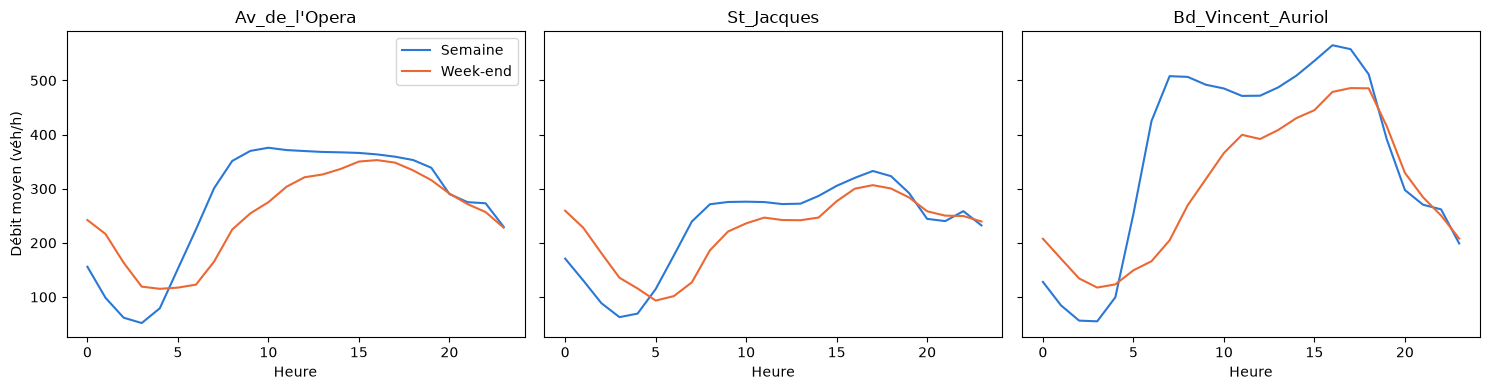

In [2]:
import matplotlib.pyplot as plt

profil = df.groupby(["libelle", "weekend", "heure"])["q"].mean().reset_index()

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

for ax, axe in zip(axes, df["libelle"].unique()):
    sous = profil[profil["libelle"] == axe]
    semaine = sous[~sous["weekend"]]
    weekend = sous[sous["weekend"]]
    ax.plot(semaine["heure"], semaine["q"], label="Semaine", color="#2a78d6")
    ax.plot(weekend["heure"], weekend["q"], label="Week-end", color="#eb6834")
    ax.set_title(axe)
    ax.set_xlabel("Heure")

axes[0].set_ylabel("Débit moyen (véh/h)")
axes[0].legend()
plt.tight_layout()
plt.show()

Sur les trois axes, on retrouve le même schéma de base : un creux nocturne très marqué (minimum vers 3h-4h du matin), puis une remontée du trafic dans la matinée. C'est la différence entre semaine et week-end qui raconte l'histoire la plus intéressante.
Sur Av_de_l'Opera et St_Jacques, la semaine montre une vraie pointe du matin (remontée brutale dès 5h-6h, pic net vers 10h-16h) typique des trajets domicile travail, alors que le week-end la hausse est beaucoup plus lente, les gens sortent plus tard et de façon plus étalée dans la journée.
Bd_Vincent_Auriol se distingue nettement des deux autres : c'est l'axe avec le plus fort contraste semaine/week-end (jusqu'à 550 véhicules par heure en semaine contre 490 véhicules le week-end), et surtout la courbe de semaine grimpe très brutalement dès 6h-7h pour atteindre un plateau élevé toute la journée  un profil typique d'un axe de transit utilisé pour les déplacements professionnels, alors que le week-end suit une montée plus douce, cohérente avec des déplacements plus loisirs/non contraints par les horaires de travail.

 **2 -  Heatmap : quand la congestion est elle maximale ?**



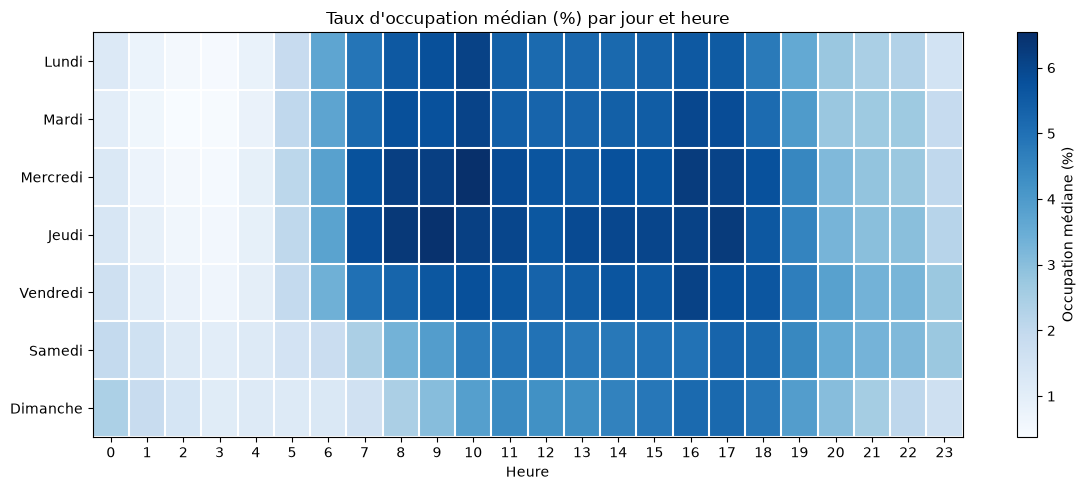

In [3]:
import numpy as np

ordre_jours = ["Lundi", "Mardi", "Mercredi", "Jeudi", "Vendredi", "Samedi", "Dimanche"]
pivot = df.pivot_table(index="jour_semaine", columns="heure", values="k", aggfunc="median")
pivot = pivot.reindex(ordre_jours)

fig, ax = plt.subplots(figsize=(12, 5))
im = ax.imshow(pivot, aspect="auto", cmap="Blues", interpolation="nearest")

ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels(pivot.index)
ax.set_xticks(range(24))
ax.set_xticklabels(range(24))
ax.set_xlabel("Heure")
ax.set_title("Taux d'occupation médian (%) par jour et heure")

ax.set_xticks(np.arange(-0.5, 24, 1), minor=True)
ax.set_yticks(np.arange(-0.5, 7, 1), minor=True)
ax.grid(which="minor", color="white", linewidth=1.5)
ax.tick_params(which="minor", length=0)

plt.colorbar(im, label="Occupation médiane (%)")
plt.tight_layout()
plt.show()

La congestion est maximale en semaine (lundi à vendredi), avec deux fenêtres qui ressortent nettement : le matin vers 8h-9h et l'après-midi/soir vers 15h-18h  c'est particulièrement marqué le jeudi et le mercredi, où l'occupation médiane dépasse les 6%. Entre ces deux pointes (11h-13h) l'occupation reste élevée mais légèrement plus basse, sans vraiment redescendre.

3 - Le diagramme fondamental

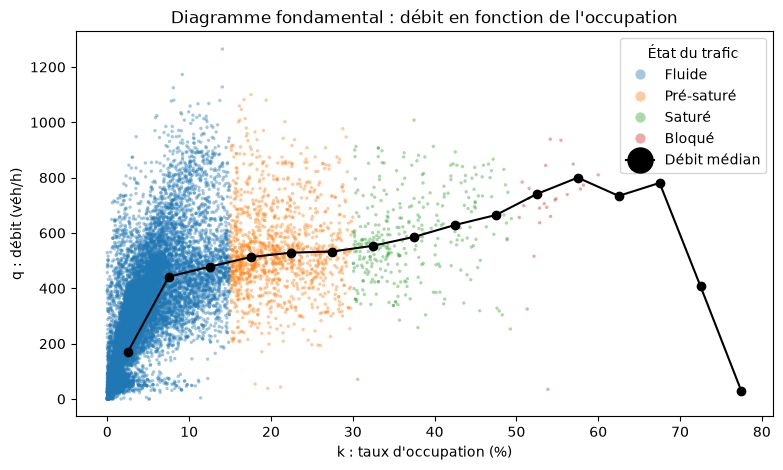

In [4]:
import seaborn as sns

ordre = ["Fluide", "Pré-saturé", "Saturé", "Bloqué"]
mapping_inverse = {i: etat for i, etat in enumerate(ordre)}
df["etat_trafic_label"] = df["etat_trafic_ord"].map(mapping_inverse)

echantillon = df.dropna(subset=["q", "k", "etat_trafic_label"]).sample(20_000, random_state=0)

plt.figure(figsize=(9, 5))
sns.scatterplot(data=echantillon, x="k", y="q", hue="etat_trafic_label", hue_order=ordre,
                s=6, alpha=0.4, linewidth=0)

classes = pd.cut(df["k"], bins=range(0, 101, 5))
mediane = df.groupby(classes, observed=True)["q"].median()
plt.plot([c.mid for c in mediane.index], mediane.values, color="black", marker="o", label="Débit médian")

plt.title("Diagramme fondamental : débit en fonction de l'occupation")
plt.xlabel("k : taux d'occupation (%)"); plt.ylabel("q : débit (véh/h)")
plt.legend(title="État du trafic", markerscale=3)
plt.show()

De 0 à environ 55, 60% d'occupation, le débit augmente avec l'occupation, plus de véhicules sont présents sur la route, et ils continuent à circuler, donc le nombre de passages par heure grimpe  c'est la phase fluide a bloqué, qui culmine vers 800 véhicules par heures aux alentours de 57% d'occupation. C'est le point de capacité maximale de l'axe au-delà, ajouter plus de véhicules ne fait plus passer plus de trafic.

In [5]:
seuils = {}
for axe in df["libelle"].unique():
    sous = df[df["libelle"] == axe]
    classes = pd.cut(sous["k"], bins=range(0, 101, 5))
    mediane = sous.groupby(classes, observed=True)["q"].median()
    pic = mediane.idxmax()
    seuils[axe] = pic.mid

seuils

{"Av_de_l'Opera": np.float64(22.5),
 'St_Jacques': np.float64(57.5),
 'Bd_Vincent_Auriol': np.float64(57.5)}

A partir de quel occupation les axes basculent ? Est ce le même seuil partout ?

Pour chaque axe, je recoupe k en tranches de 5% et je repère la tranche où le débit médian est maximal  c'est le point de bascule juste après, plus d'occupation ne fait plus monter le débit.
On peut d'aileurs remarquer que dès 22,5 % d'occupation sur l'avenue de l'opera, on peut dire que c'est un axe assez fragile, cela peut s'expliquer par moins de voies, des feux de route, carrefours ou stationnement qui bascule son état de fluide à saturé.

In [6]:
ls

README.md
data/
download_data.py
jour_1_analyse.ipynb
jour_2_types_nettoyage.ipynb
jour_3_transformation_statistiques.ipynb
jour_4_analyse.ipynb
requirements.txt
run_all.py
